In [ ]:
!pip install pytorch-tcn

In [ ]:
import pandas as pd
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split, Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from pytorch_tcn import TCN
import matplotlib.pyplot as plt
import numpy as np
import folium
import random
from typing import Tuple



import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:

df = pd.read_csv('./ibtracs_all_list_v04r01_vnm.csv')
df = df.drop(index=0).reset_index(drop=True)

df.describe()


/tmp/ipython-input-780629778.py:1: DtypeWarning: Columns (1,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./ibtracs_all_list_v04r01_vnm.csv')


,SID,NUMBER,BASIN,SUBBASIN,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
count,226152,226152,226152,226152,226152,226152,226152.0,226152.0,226152,226152
unique,4509,224,4,5,163991,6,1539.0,2426.0,58,117
top,1990309N08167,50,Western North Pacific,Missing,1985-08-15 00:00:00,Tropical,16.0,129.0,,
freq,227,2659,176307,177597,6,175191,957.0,518.0,200871,172522


In [ ]:
df.tail(10)

,SID,NUMBER,BASIN,SUBBASIN,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
226142,2025235N17117,65,Western North Pacific,Missing,2025-08-22 21:00:00,Not reported,17.3,116.9,,
226143,2025235N17117,65,Western North Pacific,Missing,2025-08-23 00:00:00,Not reported,17.5,116.6,,
226144,2025235N17117,65,Western North Pacific,Missing,2025-08-23 03:00:00,Not reported,17.6,115.9,,
226145,2025235N17117,65,Western North Pacific,Missing,2025-08-23 06:00:00,Not reported,17.6,115.0,,
226146,2025235N17117,65,Western North Pacific,Missing,2025-08-23 09:00:00,Not reported,17.8,114.3,,
226147,2025235N17117,65,Western North Pacific,Missing,2025-08-23 12:00:00,Not reported,17.9,113.6,,
226148,2025235N17117,65,Western North Pacific,Missing,2025-08-23 15:00:00,Not reported,17.6,112.9,,
226149,2025235N17117,65,Western North Pacific,Missing,2025-08-23 18:00:00,Not reported,17.2,112.2,,
226150,2025235N17117,65,Western North Pacific,Missing,2025-08-23 21:00:00,Not reported,17.1,111.6,,
226151,2025235N17117,65,Western North Pacific,Missing,2025-08-24 00:00:00,Not reported,17.2,111.1,,


In [ ]:

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def bearing(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
    brng = np.degrees(np.arctan2(x, y))
    return (brng + 360) % 360

def compute_metrics(pred: torch.Tensor, tgt: torch.Tensor) -> Tuple[float, float, float, float]:
    with torch.no_grad():
        diff = pred - tgt
        mse = torch.mean(diff ** 2).item()
        rmse = math.sqrt(mse)
        eps = 1e-6
        mape = (torch.mean(torch.abs(diff / (tgt + eps))).item()) * 100.0
    return mse, rmse, mape

In [ ]:
# --- Stepwise Temporal Fading Augmentation ---
def stfa(seq, n=1, multipliers=None):
    T = seq.size(0)
    if multipliers is None:
        multipliers = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    multipliers = torch.tensor(multipliers, dtype=seq.dtype, device=seq.device)

    faded = seq.clone()
    L = T - n
    if L <= 0:
        return faded  # nothing to fade

    S = len(multipliers)
    k, remainder = divmod(L, S)
    idx = T - n - 1

    for b, m in enumerate(reversed(multipliers)):
        band_size = k + (1 if b < remainder else 0)
        if band_size == 0 or idx < 0:
            continue
        band_indices = torch.arange(idx - band_size + 1, idx + 1, device=seq.device)
        faded[band_indices] *= m
        idx -= band_size

    return faded


# --- Base Dataset ---
class StormDataset(Dataset):
    def __init__(self, df, seq_len=10):
        self.seq_len = seq_len
        self.samples = []

        df = df.copy()
        df["LAT"] = pd.to_numeric(df["LAT"], errors="coerce")
        df["LON"] = pd.to_numeric(df["LON"], errors="coerce")
        df = df.dropna(subset=["LAT", "LON"])

        for sid, group in df.groupby("SID"):
            points = group[["LAT", "LON"]].values.astype("float32")
            if len(points) <= seq_len:
                continue

            dist_list, brng_list = [0.0], [0.0]
            for i in range(1, len(points)):
                lat1, lon1 = points[i-1]
                lat2, lon2 = points[i]
                dist_list.append(haversine(lat1, lon1, lat2, lon2))
                brng_list.append(bearing(lat1, lon1, lat2, lon2))

            dist_arr = np.array(dist_list, dtype="float32").reshape(-1, 1)
            brng_arr = (np.array(brng_list, dtype="float32") / 360.0).reshape(-1, 1)

            feats = np.hstack([points, dist_arr, brng_arr])

            for i in range(len(feats) - seq_len):
                src = torch.from_numpy(feats[i:i+seq_len])
                tgt_latlon = torch.from_numpy(points[i+1:i+seq_len+1])
                tgt_aux = torch.from_numpy(np.hstack([
                    dist_arr[i+1:i+seq_len+1],
                    brng_arr[i+1:i+seq_len+1]
                ]))
                self.samples.append((src, tgt_latlon, tgt_aux, sid))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        src, tgt_latlon, tgt_aux, sid = self.samples[idx]
        return src, tgt_latlon, tgt_aux


# --- Augmented Dataset (Include 50%) ---
class AugmentedStormDataset(Dataset):
    """
    50% of SIDs are REPLACED with their STFA-augmented versions (same dataset size).
    """
    def __init__(self, base_dataset, frac=0.5, multipliers=None, n_keep=1, seed=42):
        self.multipliers = multipliers
        self.n_keep = n_keep
        rng = random.Random(seed)
        self.samples = []

        sid_per_sample = [s[3] for s in base_dataset.samples]
        unique_sids = list(set(sid_per_sample))
        n_aug = max(1, int(len(unique_sids) * frac))
        aug_sids = set(rng.sample(unique_sids, n_aug))

        for src, tgt_latlon, tgt_aux, sid in base_dataset.samples:
            if sid in aug_sids:
                # --- Replace with augmented version ---
                latlon = src[:, :2]
                faded_latlon = stfa(latlon, n=self.n_keep, multipliers=self.multipliers)

                faded_np = faded_latlon.cpu().numpy()
                dist_list, brng_list = [0.0], [0.0]
                for i in range(1, len(faded_np)):
                    lat1, lon1 = faded_np[i - 1]
                    lat2, lon2 = faded_np[i]
                    dist_list.append(haversine(lat1, lon1, lat2, lon2))
                    brng_list.append(bearing(lat1, lon1, lat2, lon2))

                dist_arr = np.array(dist_list, dtype="float32").reshape(-1, 1)
                brng_arr = (np.array(brng_list, dtype="float32") / 360.0).reshape(-1, 1)
                new_feats = np.hstack([faded_np, dist_arr, brng_arr])
                new_src = torch.from_numpy(new_feats).to(src.dtype)

                self.samples.append((new_src, tgt_latlon, tgt_aux, sid))
            else:
                # --- Keep original ---
                self.samples.append((src, tgt_latlon, tgt_aux, sid))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        src, tgt_latlon, tgt_aux, sid = self.samples[idx]
        return src, tgt_latlon, tgt_aux


# --- Split and Prepare ---
sids = df["SID"].unique()
n_total = len(sids)
n_train = int(0.74 * n_total)
n_valid = int(0.07 * n_total)
n_test  = n_total - n_train - n_valid

train_sids = sids[:n_train]
valid_sids = sids[n_train:n_train+n_valid]
test_sids  = sids[n_train+n_valid:]

train_set_raw = StormDataset(df[df["SID"].isin(train_sids)], seq_len=4)
valid_set = StormDataset(df[df["SID"].isin(valid_sids)], seq_len=4)
test_set  = StormDataset(df[df["SID"].isin(test_sids)], seq_len=4)

# Replace 50% with STFA-augmented data
train_set = AugmentedStormDataset(
    train_set_raw,
    frac=0.5,
    multipliers=[0.98, 0.99],
    n_keep=2
)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=64, shuffle=False)

print(f"Train set size (after replace): {len(train_set)} == Original {len(train_set_raw)}")
print(f"Valid: {len(valid_set)}, Test: {len(test_set)}")


Train set size (after replace): 140658 == Original 140658
Valid: 20381, Test: 47179


In [ ]:
class StormTCN(nn.Module):
    def __init__(self, input_dim=4, hidden_units=256, num_layers=4, dropout=0.2, kernel_size=3):
        super().__init__()
        try:
            self.tcn = TCN(
                num_inputs=input_dim,
                num_channels=[hidden_units] * num_layers,
                kernel_size=kernel_size,
                dropout=dropout,
                causal=True,
                input_shape="NCL"
            )
        except TypeError:
            self.tcn = TCN(
                input_size=input_dim,
                output_size=hidden_units,
                num_channels=[hidden_units] * num_layers,
                kernel_size=kernel_size,
                dropout=dropout
            )

        self.head_latlon = nn.Linear(hidden_units, 2)
        self.head_aux = nn.Linear(hidden_units, 2)

    def forward(self, x: torch.Tensor):
        x_perm = x.permute(0, 2, 1)
        features = self.tcn(x_perm)
        if features.dim() == 3:
            features = features.permute(0, 2, 1)
        else:
            pass

        pred_latlon = self.head_latlon(features)
        pred_aux = self.head_aux(features)
        return pred_latlon, pred_aux

def haversine_loss(pred, target):
    R = 6371.0
    lat1, lon1 = torch.deg2rad(pred[..., 0]), torch.deg2rad(pred[..., 1])
    lat2, lon2 = torch.deg2rad(target[..., 0]), torch.deg2rad(target[..., 1])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = torch.sin(dlat / 2) ** 2 + torch.cos(lat1) * torch.cos(lat2) * torch.sin(dlon / 2) ** 2
    c = 2 * torch.atan2(torch.sqrt(a), torch.sqrt(1 - a))
    return torch.mean(R * c)

def train_tcn_model(
    train_loader,
    valid_loader,
    device=None,
    input_dim=4,
    hidden_units=1024,
    num_layers=2,
    lr=1e-4,
    lambda_aux=0.5,
    lambda_hav=0.3,
    epochs=80,
    patience=4
):

    model = StormTCN(input_dim=input_dim, hidden_units=hidden_units, num_layers=num_layers).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=0, min_lr=1e-6)

    val_best = float('inf')
    counter = 0
    history = {"train_loss": [], "val_loss": [], "mse": [], "mape": [], 'rmse': [], "haversine": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for src, tgt_latlon, tgt_aux in loop:
            src, tgt_latlon, tgt_aux = src.to(device), tgt_latlon.to(device), tgt_aux.to(device)

            pred_latlon, pred_aux = model(src)

            loss_main = criterion(pred_latlon, tgt_latlon)
            loss_aux = criterion(pred_aux, tgt_aux)
            loss_hav = haversine_loss(pred_latlon, tgt_latlon)

            loss = loss_main + lambda_aux * loss_aux + lambda_hav * loss_hav

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            loop.set_postfix(batch_loss=loss.item(), mean_loss=total_loss / (loop.n + 1))

        train_loss = total_loss / len(train_loader)

        # Validation phase
        model.eval()
        val_loss = mse_sum = mae_sum = rmse_sum = mape_sum = haversine_sum = 0.0
        n_batches = 0

        with torch.no_grad():
            for src, tgt_latlon, tgt_aux in tqdm(valid_loader, leave=False, desc="Valid"):
                src, tgt_latlon, tgt_aux = src.to(device), tgt_latlon.to(device), tgt_aux.to(device)
                pred_latlon, pred_aux = model(src)

                loss_main = criterion(pred_latlon, tgt_latlon)
                loss_aux = criterion(pred_aux, tgt_aux)
                loss_hav = haversine_loss(pred_latlon, tgt_latlon)
                loss = loss_main + lambda_aux * loss_aux + lambda_hav * loss_hav
                val_loss += loss.item()

                mse, rmse, mape = compute_metrics(pred_latlon, tgt_latlon)
                mse_sum += mse
                rmse_sum += rmse
                mape_sum += mape

                p_np = pred_latlon.detach().cpu().numpy().reshape(-1, 2)
                t_np = tgt_latlon.detach().cpu().numpy().reshape(-1, 2)
                hs = haversine(p_np[:, 0], p_np[:, 1], t_np[:, 0], t_np[:, 1])
                haversine_sum += float(np.mean(hs))
                n_batches += 1

        val_loss /= max(1, len(valid_loader))
        mean_mse = mse_sum / len(valid_loader)
        mean_rmse = rmse_sum / len(valid_loader)
        mean_mape = mape_sum / len(valid_loader)
        mean_haversine = haversine_sum / max(1, n_batches)

        print(
            f"Epoch {epoch+1} | "
            f"Train {train_loss:.4f} | Val {val_loss:.4f} | "
            f"MSE {mean_mse:.4f} | RMSE {mean_rmse:.4f} | "
            f"MAPE {mean_mape:.2f}% | Haversine {mean_haversine:.2f} km"
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["mse"].append(mean_mse)
        history["mape"].append(mean_mape)
        history['rmse'].append(mean_rmse)
        history["haversine"].append(mean_haversine)

        scheduler.step(val_loss)

        if val_loss < val_best:
            val_best = val_loss
            torch.save(model.state_dict(), "model_stfa.pth")
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"\n Early stopping triggered at epoch {epoch+1} (no improvement in {patience} epochs)")
                break

    model.load_state_dict(torch.load("model_stfa.pth", map_location=device))

    return model, history

trained_model, history = train_tcn_model(
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=device)


Epoch 1/80: 100%|██████████| 2198/2198 [00:29<00:00, 74.09it/s, batch_loss=165, mean_loss=229]


Epoch 1 | Train 228.1999 | Val 92.5219 | MSE 1.0238 | RMSE 0.9860 | MAPE 1.32% | Haversine 127.04 km


Epoch 2/80: 100%|██████████| 2198/2198 [00:30<00:00, 72.98it/s, batch_loss=135, mean_loss=138]


Epoch 2 | Train 137.4920 | Val 67.8196 | MSE 0.2298 | RMSE 0.4629 | MAPE 0.96% | Haversine 57.28 km


Epoch 3/80: 100%|██████████| 2198/2198 [00:29<00:00, 74.62it/s, batch_loss=124, mean_loss=128]


...

Epoch 17 | Train 109.2274 | Val 58.5766 | MSE 0.0726 | RMSE 0.2556 | MAPE 0.58% | Haversine 28.60 km


Epoch 18/80: 100%|██████████| 2198/2198 [00:30<00:00, 71.51it/s, batch_loss=58.6, mean_loss=109]


Epoch 18 | Train 109.0905 | Val 58.1212 | MSE 0.0716 | RMSE 0.2535 | MAPE 0.58% | Haversine 28.11 km


Epoch 19/80: 100%|██████████| 2198/2198 [00:29<00:00, 74.50it/s, batch_loss=80.8, mean_loss=109]


Epoch 19 | Train 109.1089 | Val 58.3777 | MSE 0.0718 | RMSE 0.2538 | MAPE 0.57% | Haversine 28.14 km

 Early stopping triggered at epoch 19 (no improvement in 6 epochs)


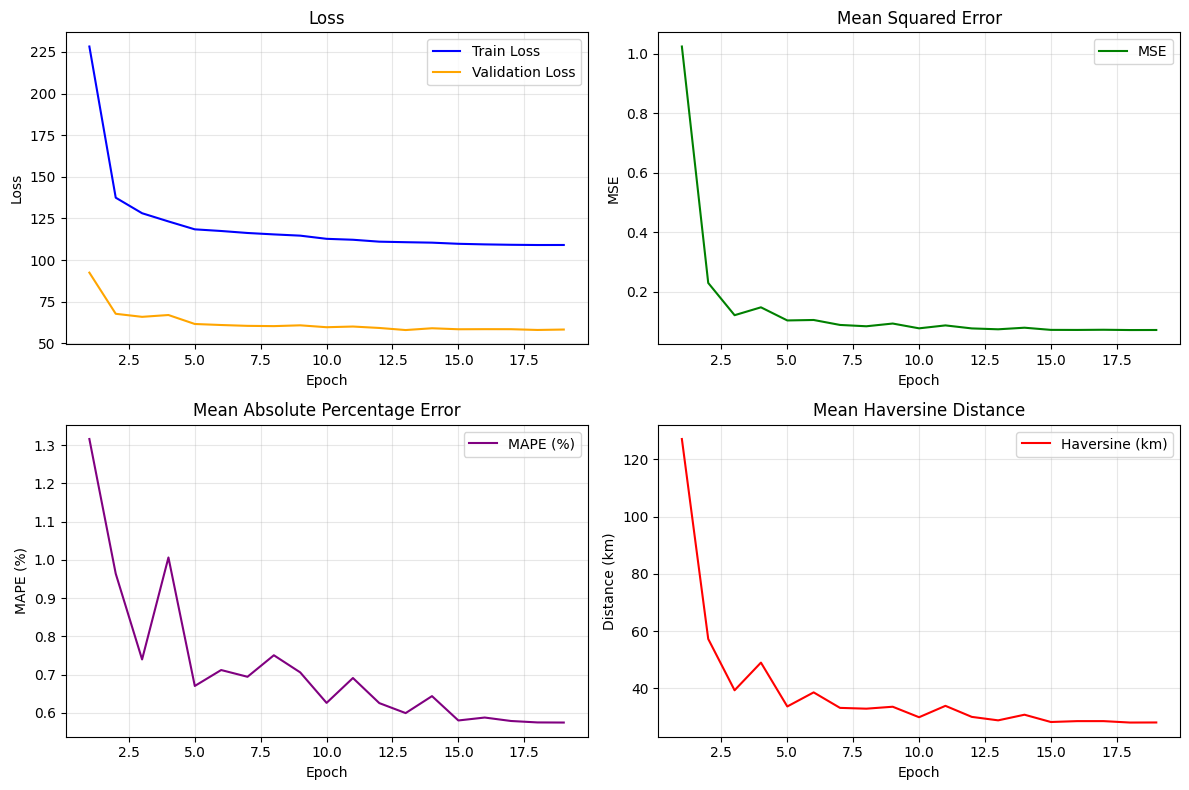

In [ ]:

def plot_training_history(history):
    epochs_r = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(12, 8))

    # --- 1. Train vs Validation Loss ---
    plt.subplot(2, 2, 1)
    plt.plot(epochs_r, history["train_loss"], label="Train Loss", color="blue")
    plt.plot(epochs_r, history["val_loss"], label="Validation Loss", color="orange")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    # --- 2. MSE ---
    plt.subplot(2, 2, 2)
    plt.plot(epochs_r, history["mse"], label="MSE", color="green")
    plt.title("Mean Squared Error")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(alpha=0.3)

    # --- 3. MAPE ---
    plt.subplot(2, 2, 3)
    plt.plot(epochs_r, history["mape"], label="MAPE (%)", color="purple")
    plt.title("Mean Absolute Percentage Error")
    plt.xlabel("Epoch")
    plt.ylabel("MAPE (%)")
    plt.legend()
    plt.grid(alpha=0.3)

    # --- 4. Haversine Distance ---
    plt.subplot(2, 2, 4)
    plt.plot(epochs_r, history["haversine"], label="Haversine (km)", color="red")
    plt.title("Mean Haversine Distance")
    plt.xlabel("Epoch")
    plt.ylabel("Distance (km)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history)


In [ ]:

def evaluate_tcn_model(model, test_loader, device, lambda_aux=0.5, lambda_hav=0.3):
    model.eval()
    criterion = torch.nn.MSELoss()

    val_loss = mse_sum = mae_sum = rmse_sum = mape_sum = haversine_sum = 0.0
    n_batches = 0

    with torch.no_grad():
        for src, tgt_latlon, tgt_aux in tqdm(test_loader, desc="Testing", leave=True):
            src, tgt_latlon, tgt_aux = src.to(device), tgt_latlon.to(device), tgt_aux.to(device)
            pred_latlon, pred_aux = model(src)

            loss_main = criterion(pred_latlon, tgt_latlon)
            loss_aux = criterion(pred_aux, tgt_aux)
            loss_hav = haversine_loss(pred_latlon, tgt_latlon)
            loss = loss_main + lambda_aux * loss_aux + lambda_hav * loss_hav
            val_loss += loss.item()

            mse, rmse, mape = compute_metrics(pred_latlon, tgt_latlon)
            mse_sum += mse
            rmse_sum += rmse
            mape_sum += mape

            p_np = pred_latlon.detach().cpu().numpy().reshape(-1, 2)
            t_np = tgt_latlon.detach().cpu().numpy().reshape(-1, 2)
            hs = haversine(p_np[:, 0], p_np[:, 1], t_np[:, 0], t_np[:, 1])
            haversine_sum += float(np.mean(hs))

            n_batches += 1

    val_loss /= max(1, len(test_loader))
    mean_mse = mse_sum / n_batches
    mean_rmse = rmse_sum / n_batches
    mean_mape = mape_sum / n_batches
    mean_haversine = haversine_sum / n_batches

    print("\n Test Evaluation Summary")
    print(f"---------------------------------------------")
    print(f"Total Loss     : {val_loss:.4f}")
    print(f"MSE            : {mean_mse:.4f}")
    print(f"RMSE           : {mean_rmse:.4f}")
    print(f"MAPE (%)       : {mean_mape:.2f}%")
    print(f"Haversine (km) : {mean_haversine:.2f}")
    print(f"---------------------------------------------")

    return {
        "loss": val_loss,
        "mse": mean_mse,
        "rmse": mean_rmse,
        "mape": mean_mape,
        "haversine": mean_haversine
    }

test_metrics = evaluate_tcn_model(trained_model, test_loader, device=device)


Testing: 100%|██████████| 738/738 [00:02<00:00, 278.90it/s]


 Test Evaluation Summary
---------------------------------------------
Total Loss     : 74.3849
MSE            : 0.0832
RMSE           : 0.2772
MAPE (%)       : 0.60%
Haversine (km) : 30.75
---------------------------------------------
